In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
print('✓ Additional libraries loaded!')

✓ Additional libraries loaded!


In [2]:
train_dir = r"G:\Dementia\Starting\Splitted\train"
val_dir   = r"G:\Dementia\Starting\Splitted\val"
test_dir  = r"G:\Dementia\Starting\Splitted\test"

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Augmentation for training only
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


Found 4479 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.
Found 642 images belonging to 4 classes.


In [4]:
base_model = EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# PHASE 1: Freeze entire backbone
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
# NO Dense(128)! Go directly to output
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  # Higher LR for warmup
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

print("=== PHASE 1: Warmup (frozen backbone) ===")
model.fit(
    train_gen, validation_data=val_gen,
    epochs=10, callbacks=[early_stop]
)

=== PHASE 1: Warmup (frozen backbone) ===
Epoch 1/10
 41/140 ━━━━━━━━━━━━━━━━━━━━ 1:39 1s/step - accuracy: 0.4502 - loss: 1.1853  

In [6]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== PHASE 2: Fine-tuning (last 40 layers) ===")
model.fit(
    train_gen, validation_data=val_gen,
    epochs=20, callbacks=[early_stop]
)

=== PHASE 2: Fine-tuning (last 40 layers) ===
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.3442 - loss: 1.4221 - val_accuracy: 0.5614 - val_loss: 0.9461
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.5530 - loss: 1.0072 - val_accuracy: 0.5512 - val_loss: 0.9353
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5604 - loss: 0.9541 - val_accuracy: 0.5496 - val_loss: 0.9110
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5835 - loss: 0.9099 - val_accuracy: 0.5661 - val_loss: 0.8897
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.5815 - loss: 0.8874 - val_accuracy: 0.5700 - val_loss: 0.8816


In [7]:
feature_extractor = Model(
    inputs=model.input,
    outputs=model.layers[-3].output  # GlobalAveragePooling2D → 1280 features
)

def extract_features(generator, extractor):
    generator.reset()
    features = extractor.predict(generator, verbose=1)
    labels = generator.classes
    return features, labels

# Use NO-augmentation generators for feature extraction
extract_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_gen_noaug = extract_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

X_train, y_train = extract_features(train_gen_noaug, feature_extractor)
X_val,   y_val   = extract_features(val_gen, feature_extractor)
X_test,  y_test  = extract_features(test_gen, feature_extractor)

print(f"Feature shape: {X_train.shape}")  # Should be (N, 1280)


Found 4479 images belonging to 4 classes.
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 681ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 651ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 700ms/step
Feature shape: (4479, 1280)


In [8]:
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

classes = np.unique(y_train_full)
weights = compute_class_weight('balanced', classes=classes, y=y_train_full)
sample_weights = np.array([weights[y] for y in y_train_full])

In [9]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    objective='multi:softprob',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_full, y_train_full, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [ ]:
y_pred_proba = xgb_model.predict_proba(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']))

Accuracy: 0.9143302180685359
              precision    recall  f1-score   support

 NonDemented       0.95      0.86      0.90        90
    VeryMild       1.00      1.00      1.00         8
        Mild       0.92      0.95      0.94       320
    Moderate       0.89      0.88      0.89       224

    accuracy                           0.91       642
   macro avg       0.94      0.92      0.93       642
weighted avg       0.91      0.91      0.91       642



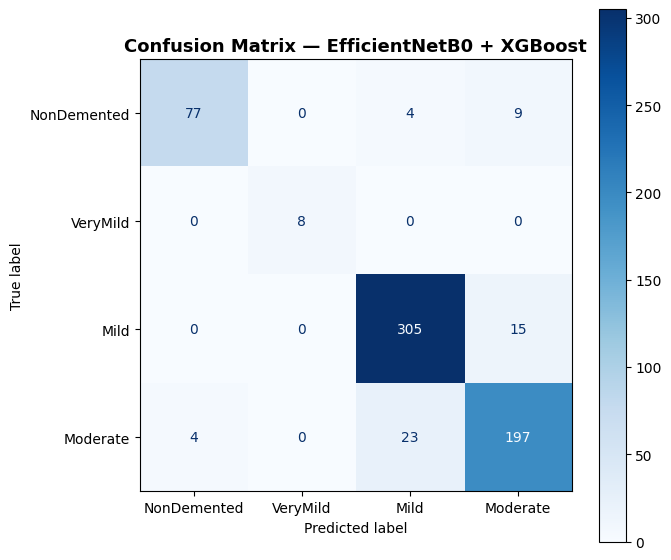

✓ Confusion matrix plotted!


In [ ]:
CLASS_NAMES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=CLASS_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — EfficientNetB0 + XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Confusion matrix plotted!')

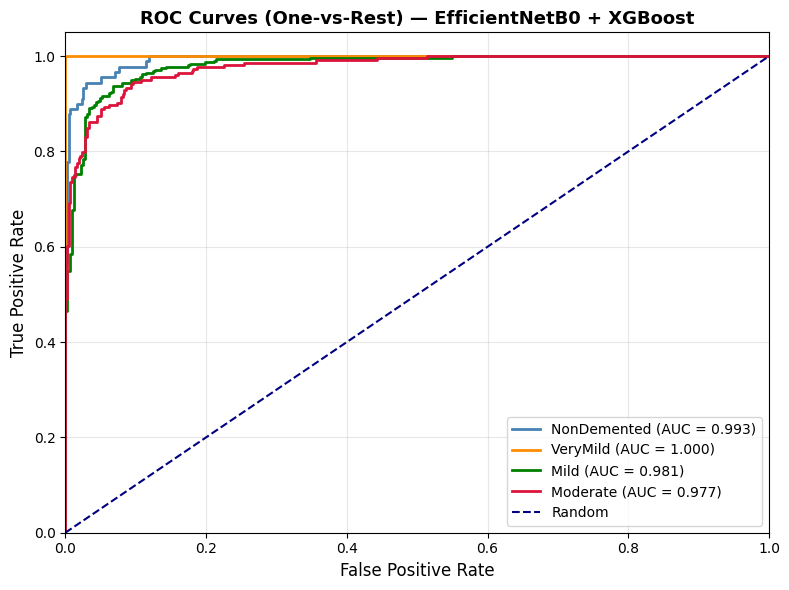

Macro-average ROC-AUC: 0.9878
✓ ROC curves plotted!


In [14]:
# One-vs-Rest ROC curves for all 4 classes
n_classes = 4
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green', 'crimson']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name} (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves (One-vs-Rest) — EfficientNetB0 + XGBoost',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
print(f'Macro-average ROC-AUC: {macro_auc:.4f}')
print('✓ ROC curves plotted!')

C:\Users\junai\AppData\Local\Temp\ipykernel_5372\3905659162.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df_mri,


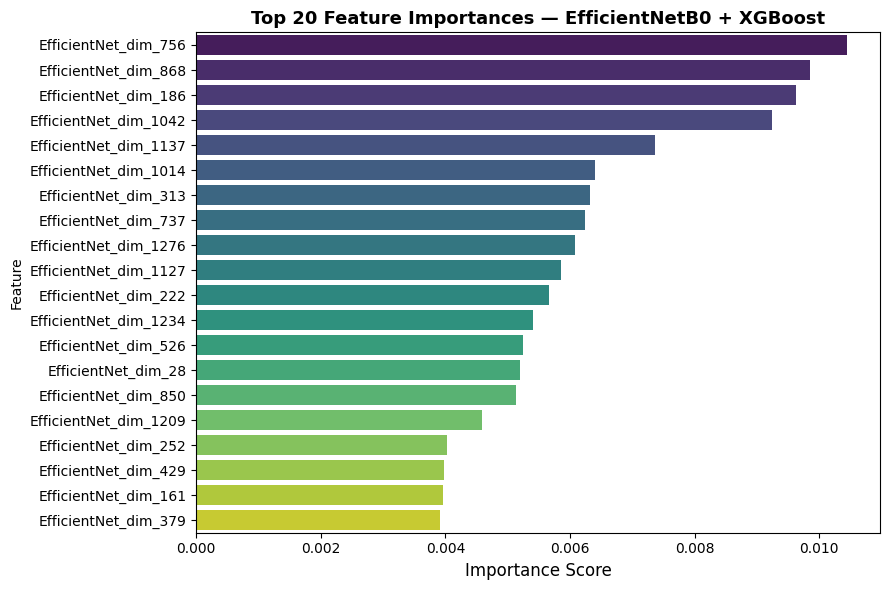

✓ Feature importance plot shown!


In [15]:
# XGBoost feature importances over the 1280 EfficientNet embedding dims
importances = xgb_model.feature_importances_
top_n = 20
top_idx = importances.argsort()[::-1][:top_n]

feat_df_mri = {
    'Feature': [f'EfficientNet_dim_{i}' for i in top_idx],
    'Importance': importances[top_idx]
}

import pandas as pd
feat_df_mri = pd.DataFrame(feat_df_mri)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df_mri,
            palette='viridis', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances — EfficientNetB0 + XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()
print('✓ Feature importance plot shown!')

C:\Users\junai\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

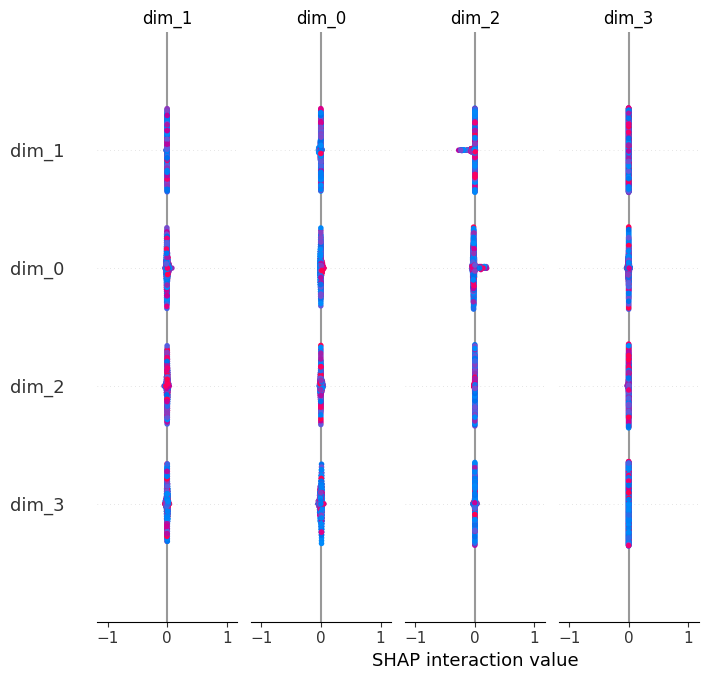

✓ SHAP summary plot shown!


In [16]:
try:
    import shap

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test[:500])

    # shap_values shape: (n_samples, n_features, n_classes) for multiclass
    # Plot for each class or summarise across classes
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_test[:500],
        feature_names=[f'dim_{i}' for i in range(X_test.shape[1])],
        class_names=CLASS_NAMES,
        show=True
    )
    print('✓ SHAP summary plot shown!')
except ImportError:
    print('⚠ SHAP not installed. Run: pip install shap')
except Exception as e:
    print(f'⚠ SHAP error: {e}')

In [17]:
# Save the fine-tuned Keras model
model.save('mri_efficientnet_finetuned.keras')

# Save the XGBoost classifier
joblib.dump(xgb_model, 'mri_xgb_model.pkl')

print('✓ Models saved:')
print('  📁 mri_efficientnet_finetuned.keras   (EfficientNetB0 feature extractor)')
print('  📁 mri_xgb_model.pkl                  (XGBoost classifier)')

✓ Models saved:
  📁 mri_efficientnet_finetuned.keras   (EfficientNetB0 feature extractor)
  📁 mri_xgb_model.pkl                  (XGBoost classifier)
